In [1]:
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bigfish.stack as stack

# Load data

In [2]:
root_path = Path("/data/smfish/20260311_bartelle_smFISH_cryo_48hr_male")

In [3]:
results_dir = (
        root_path
        / "big_fish"
        / "results"
        / "all_tiles_2D"
    )

# -------------------------------------------------------------------------
# Load segmentation to get ALL cell IDs
# -------------------------------------------------------------------------
cellpose_path = (
    root_path
    / "big_fish"
    / "segmentation"
    / "fiducial_no_downsampling_masks.ome.tiff"
)

print("Loading segmentation...")
cell_label = stack.read_image(str(cellpose_path))

# Cellpose background = 0, so exclude it
cell_ids = np.unique(cell_label)
cell_ids = cell_ids[cell_ids != 0]

print(f"Total segmented cells: {len(cell_ids):,}")

Loading segmentation...
Total segmented cells: 9,798


In [4]:
# -------------------------------------------------------------------------
# Load spots from all 16 bits
# -------------------------------------------------------------------------
all_spots = []

for bit in range(1, 17):

    spots_path = results_dir / f"spots_bit_{bit}.csv"

    if not spots_path.exists():
        print(f"WARNING: {spots_path.name} not found. Skipping.")
        continue

    spots = pd.read_csv(spots_path)
    print(spots.head())

    if "cell_id" not in spots.columns:
        raise ValueError(
            f"{spots_path.name} does not contain a cell_id column."
        )

    # Explicitly record bit number.
    # This avoids depending on how the bit_# column is formatted.
    spots["bit"] = bit

    all_spots.append(spots)

    print(f"Bit {bit:2d}: {len(spots):,} spots")

all_spots = pd.concat(all_spots, ignore_index=True)

print()
# print(f"Total detected spots: {len(all_spots):,}")

   spot_id    y     x  bit  cell_id
0        0  311  3657    1        0
1        1  338  4340    1       10
2        2  473  4679    1        0
3        3  596  7843    1        0
4        4  652  4414    1       69
Bit  1: 4,389 spots
   spot_id    y     x  bit  cell_id
0        0   52  1967    2        1
1        1  116  3358    2        6
2        2  120  3373    2        6
3        3  120  3405    2        6
4        4  121  2971    2        0
Bit  2: 408,603 spots
   spot_id    y     x  bit  cell_id
0        0   85  2669    3        0
1        1   97  2763    3        0
2        2  132  3377    3        6
3        3  201  4382    3       10
4        4  232  4811    3       15
Bit  3: 31,452 spots
   spot_id    y     x  bit  cell_id
0        0  126  2736    4        0
1        1  162  3372    4        6
2        2  164  3348    4        6
3        3  168  3437    4        6
4        4  172  3347    4        6
Bit  4: 258,931 spots
   spot_id    y     x  bit  cell_id
0        0  201

In [8]:
all_spots.tail()

,spot_id,y,x,bit,cell_id
1104327,26232,27683,19715,16,9787
1104328,26233,27692,19934,16,0
1104329,26234,27724,19724,16,9787
1104330,26235,27726,19633,16,9787
1104331,26236,27844,20236,16,0


# Count spots/cell and genes expressed/cell

In [5]:
# -------------------------------------------------------------------------
# Remove spots outside segmented cells
#
# cell_id == 0 means the spot falls outside a Cellpose mask.
# -------------------------------------------------------------------------
spots_in_cells = all_spots[all_spots["cell_id"] != 0].copy()

print(f"Spots inside cells:   {len(spots_in_cells):,}")
print(
    f"Spots outside cells:  "
    f"{len(all_spots) - len(spots_in_cells):,}"
)

# -------------------------------------------------------------------------
# Build cell-level table
# -------------------------------------------------------------------------
cell_stats = pd.DataFrame({
    "cell_id": cell_ids
})

# -------------------------------------------------------------------------
# 1. Total number of spots per cell across ALL bits
# -------------------------------------------------------------------------
spots_per_cell = (
    spots_in_cells
    .groupby("cell_id")
    .size()
    .rename("n_spots")
)

cell_stats = cell_stats.merge(
    spots_per_cell,
    left_on="cell_id",
    right_index=True,
    how="left",
)

cell_stats["n_spots"] = (
    cell_stats["n_spots"]
    .fillna(0)
    .astype(int)
)

Spots inside cells:   660,099
Spots outside cells:  444,233


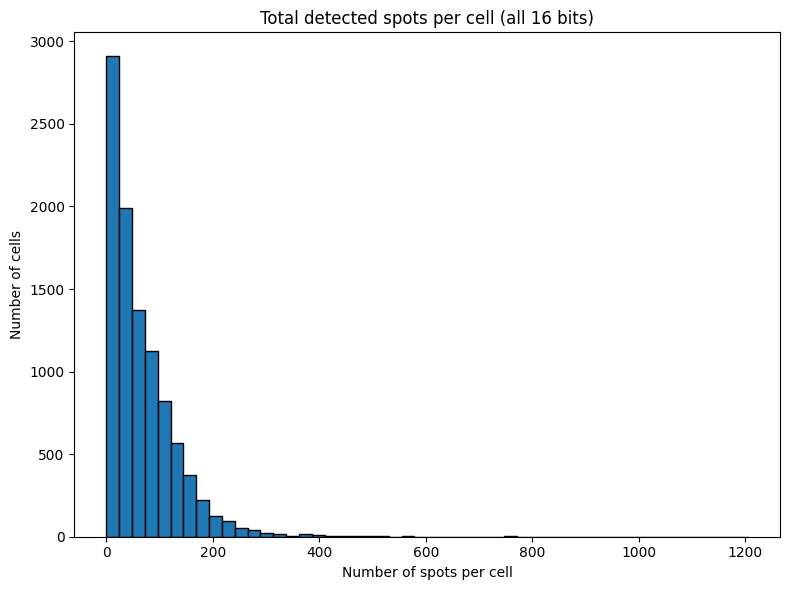

In [10]:
plt.figure(figsize=(8, 6))

plt.hist(
    cell_stats["n_spots"],
    bins=50,
    edgecolor="black",
)

plt.xlabel("Number of spots per cell")
plt.ylabel("Number of cells")
plt.title("Total detected spots per cell (all 16 bits)")

plt.tight_layout()

output_plot = results_dir / "histogram_spots_per_cell.png"

plt.savefig(
    output_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [11]:
# -------------------------------------------------------------------------
# 2. Number of unique bits/genes detected per cell
# -------------------------------------------------------------------------
genes_per_cell = (
    spots_in_cells
    .groupby("cell_id")["bit"]
    .nunique()
    .rename("n_genes")
)

cell_stats = cell_stats.merge(
    genes_per_cell,
    left_on="cell_id",
    right_index=True,
    how="left",
)

cell_stats["n_genes"] = (
    cell_stats["n_genes"]
    .fillna(0)
    .astype(int)
)

# -------------------------------------------------------------------------
# Save cell-level statistics
# -------------------------------------------------------------------------
output_csv = results_dir / "cell_spot_statistics.csv"

cell_stats.to_csv(output_csv, index=False)

print()
print(f"Saved cell statistics to:")
print(f"  {output_csv}")

# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------
print()
print("Cell-level summary")
print("------------------")
print(f"Cells:                  {len(cell_stats):,}")
print(f"Mean spots/cell:        {cell_stats['n_spots'].mean():.2f}")
print(f"Median spots/cell:      {cell_stats['n_spots'].median():.1f}")
print(f"Max spots/cell:         {cell_stats['n_spots'].max():,}")
print(f"Mean genes/cell:        {cell_stats['n_genes'].mean():.2f}")
print(f"Median genes/cell:      {cell_stats['n_genes'].median():.1f}")
print(f"Max genes/cell:         {cell_stats['n_genes'].max()}")



Saved cell statistics to:
  /data/smfish/20260311_bartelle_smFISH_cryo_48hr_male/big_fish/results/all_tiles_2D/cell_spot_statistics.csv

Cell-level summary
------------------
Cells:                  9,798
Mean spots/cell:        67.37
Median spots/cell:      48.0
Max spots/cell:         1,205
Mean genes/cell:        6.62
Median genes/cell:      7.0
Max genes/cell:         16


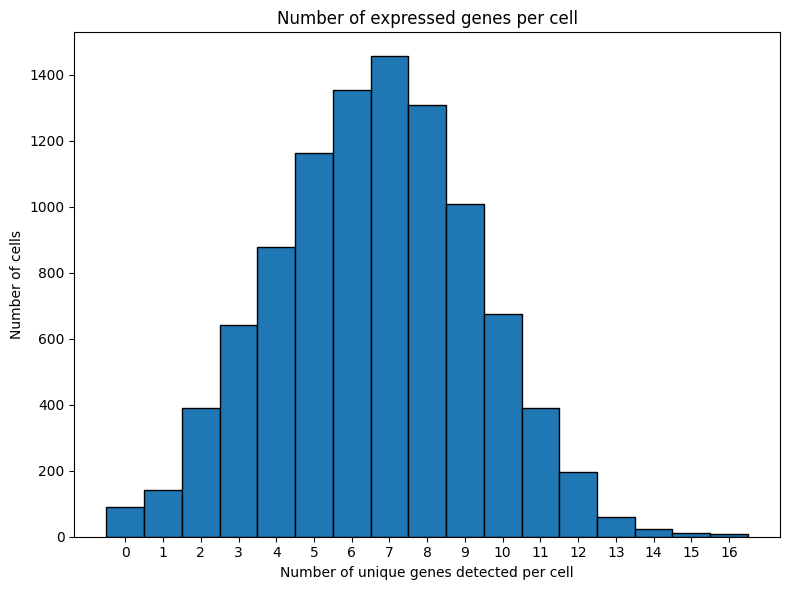

In [12]:
# =====================================================================
# HISTOGRAM 2
# Number of unique genes/bits per cell
#
# Since there are exactly 16 possible values, integer-centered bins
# make this histogram easier to interpret.
# =====================================================================

plt.figure(figsize=(8, 6))

bins = np.arange(-0.5, 17.5, 1)

plt.hist(
    cell_stats["n_genes"],
    bins=bins,
    edgecolor="black",
)

plt.xticks(range(17))

plt.xlabel("Number of unique genes detected per cell")
plt.ylabel("Number of cells")
plt.title("Number of expressed genes per cell")

plt.tight_layout()

output_plot = results_dir / "histogram_genes_per_cell.png"

plt.savefig(
    output_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [13]:
# print(spots_in_cells)
spots_per_bit = spots_in_cells["bit"].value_counts().sort_index()
print(spots_per_bit)

bit
1       1641
2     289240
3      20893
4     180248
5       7741
6       5598
7      25329
8       3728
9       6512
10     59071
11     12192
12      3436
13      9869
14      9289
15     12779
16     12533
Name: count, dtype: int64


# Cell-based analysis of markers

In [15]:
# ---------------------------------------------------------
# Create cell x bit count matrix
# ---------------------------------------------------------

# Count the number of spots for each bit in each cell
cell_bit_counts = (
    all_spots.groupby(["cell_id", "bit"])
    .size()
    .unstack(fill_value=0)
)

# Make sure all 16 bit columns exist
cell_bit_counts = cell_bit_counts.reindex(
    columns=range(1, 17),
    fill_value=0
)

# Rename columns to make it clear that they represent bits
cell_bit_counts.columns = [
    f"bit_{bit}" for bit in cell_bit_counts.columns
]

# Convert cell_id from index back into a regular column
cell_bit_counts = cell_bit_counts.reset_index()

print(cell_bit_counts.head())

   cell_id  bit_1   bit_2  bit_3  bit_4  bit_5  bit_6  bit_7  bit_8  bit_9  \
0        0   2748  119363  10559  78683  13164  10057  18360   8594   4103   
1        1      0       1      0      0      0      0      0      0      0   
2        3      0       0      0      0      0      0      1      0      0   
3        5      0       1      0      0      0      0      3      0      0   
4        6      0      35      1     15      0      0      1      0      0   

   bit_10  bit_11  bit_12  bit_13  bit_14  bit_15  bit_16  
0  103261    9700    8471   15820   13410   14236   13704  
1       1       0       0       0       0       0       0  
2       1       0       0       0       0       0       0  
3       9       0       0       0       0       0       3  
4       1       0       0       0       0       0       0  


In [15]:
# Microglia markers: bits 5 and 15
bit5_cells = (cell_bit_counts["bit_5"] > 0).sum()
bit15_cells = (cell_bit_counts["bit_15"] > 0).sum()

bit5_and_15_cells = (
    (cell_bit_counts["bit_5"] > 0) &
    (cell_bit_counts["bit_15"] > 0)
).sum()

print("Microglia markers:")
print(f"  Bit 5:       {bit5_cells}")
print(f"  Bit 15:      {bit15_cells}")
print(f"  Bits 5 & 15: {bit5_and_15_cells}")


# Neural progenitor markers: bits 3 and 16
bit3_cells = (cell_bit_counts["bit_3"] > 0).sum()
bit16_cells = (cell_bit_counts["bit_16"] > 0).sum()

bit3_and_16_cells = (
    (cell_bit_counts["bit_3"] > 0) &
    (cell_bit_counts["bit_16"] > 0)
).sum()

print("\nNeural progenitor markers:")
print(f"  Bit 3:       {bit3_cells}")
print(f"  Bit 16:      {bit16_cells}")
print(f"  Bits 3 & 16: {bit3_and_16_cells}")


# Astrocyte marker: bit 10
bit10_cells = (cell_bit_counts["bit_10"] > 0).sum()

print("\nAstrocyte marker:")
print(f"  Bit 10:      {bit10_cells}")

Microglia markers:
  Bit 5:       2742
  Bit 15:      4644
  Bits 5 & 15: 1904

Neural progenitor markers:
  Bit 3:       5558
  Bit 16:      2602
  Bits 3 & 16: 1834

Astrocyte marker:
  Bit 10:      7943


In [16]:
# Create Boolean masks for each cell type
microglia = (
    (cell_bit_counts["bit_5"] > 0) |
    (cell_bit_counts["bit_15"] > 0)
)

neural_progenitor = (
    (cell_bit_counts["bit_3"] > 0) |
    (cell_bit_counts["bit_16"] > 0)
)

astrocyte = cell_bit_counts["bit_10"] > 0

In [17]:
cell_bit_counts["microglia"] = microglia
cell_bit_counts["neural_progenitor"] = neural_progenitor
cell_bit_counts["astrocyte"] = astrocyte

In [18]:
def print_positive(label, mask):
    n = mask.sum()
    percent = n / total_cells * 100
    print(f"{label:<20} {n:>5} cells ({percent:5.2f}%)")

In [19]:
total_cells = len(cell_bit_counts)

bit5 = cell_bit_counts["bit_5"] > 0
bit15 = cell_bit_counts["bit_15"] > 0
bit3 = cell_bit_counts["bit_3"] > 0
bit16 = cell_bit_counts["bit_16"] > 0
bit10 = cell_bit_counts["bit_10"] > 0

print(f"Total cells: {total_cells}\n")

print_positive("Bit 5", bit5)
print_positive("Bit 15", bit15)
print_positive("Bits 5 & 15", bit5 & bit15)

print()

print_positive("Bit 3", bit3)
print_positive("Bit 16", bit16)
print_positive("Bits 3 & 16", bit3 & bit16)

print()

print_positive("Bit 10", bit10)

Total cells: 9709

Bit 5                 2742 cells (28.24%)
Bit 15                4644 cells (47.83%)
Bits 5 & 15           1904 cells (19.61%)

Bit 3                 5558 cells (57.25%)
Bit 16                2602 cells (26.80%)
Bits 3 & 16           1834 cells (18.89%)

Bit 10                7943 cells (81.81%)


In [20]:
label_cols = [
    "microglia",
    "neural_progenitor",
    "astrocyte"
]

cell_bit_counts["n_labels"] = (
    cell_bit_counts[label_cols].sum(axis=1)
)

In [21]:
multiple_labels = (cell_bit_counts["n_labels"] > 1).sum()
no_labels = (cell_bit_counts["n_labels"] == 0).sum()

print_positive(
    "Multiple labels",
    cell_bit_counts["n_labels"] > 1
)

print_positive(
    "No labels",
    cell_bit_counts["n_labels"] == 0
)

Multiple labels       6973 cells (71.82%)
No labels              649 cells ( 6.68%)


In [22]:
print("\nNumber of labels per cell:")

for n in range(4):
    count = (cell_bit_counts["n_labels"] == n).sum()
    percent = count / total_cells * 100

    print(f"{n} labels: {count:>5} cells ({percent:5.2f}%)")


Number of labels per cell:
0 labels:   649 cells ( 6.68%)
1 labels:  2087 cells (21.50%)
2 labels:  3255 cells (33.53%)
3 labels:  3718 cells (38.29%)


In [23]:
filename = results_dir / "cellxgene_matrix.csv"
cell_bit_counts.to_csv(filename)

In [24]:
multi_label_cells = cell_bit_counts[
    cell_bit_counts["n_labels"] > 1
].copy()

multi_label_cells.head()

,cell_id,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_11,bit_12,bit_13,bit_14,bit_15,bit_16,microglia,neural_progenitor,astrocyte,n_labels
0,0,2748,119363,10559,78683,13164,10057,18360,8594,4103,...,9700,8471,15820,13410,14236,13704,True,True,True,3
3,5,0,1,0,0,0,0,3,0,0,...,0,0,0,0,0,3,False,True,True,2
4,6,0,35,1,15,0,0,1,0,0,...,0,0,0,0,0,0,False,True,True,2
5,7,0,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,True,False,True,2
8,10,1,26,3,17,0,0,2,0,0,...,0,0,0,0,0,0,False,True,True,2


# change column names from bits to genes

In [16]:
gene_names = [
    "Angpt1",
    "Crmp1",
    "Dcx",
    "Hdac11",
    "Itgam",
    "Notch2",
    "Ptch1",
    "Serpine1",
    "Shh",
    "Slc1a3",
    "Tcf12",
    "Tek",
    "Tgfb1",
    "Tgfbi",
    "Aif1",
    "Nnat",
]

In [17]:
cell_bit_counts.head()

,cell_id,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,bit_10,bit_11,bit_12,bit_13,bit_14,bit_15,bit_16
0,0,2748,119363,10559,78683,13164,10057,18360,8594,4103,103261,9700,8471,15820,13410,14236,13704
1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,3,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
3,5,0,1,0,0,0,0,3,0,0,9,0,0,0,0,0,3
4,6,0,35,1,15,0,0,1,0,0,1,0,0,0,0,0,0


In [18]:
rename_dict = {
    f"bit_{i}": gene
    for i, gene in enumerate(gene_names, start=1)
}

cell_bit_counts = cell_bit_counts.rename(columns=rename_dict)

In [19]:
cell_bit_counts.head()

,cell_id,Angpt1,Crmp1,Dcx,Hdac11,Itgam,Notch2,Ptch1,Serpine1,Shh,Slc1a3,Tcf12,Tek,Tgfb1,Tgfbi,Aif1,Nnat
0,0,2748,119363,10559,78683,13164,10057,18360,8594,4103,103261,9700,8471,15820,13410,14236,13704
1,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,3,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0
3,5,0,1,0,0,0,0,3,0,0,9,0,0,0,0,0,3
4,6,0,35,1,15,0,0,1,0,0,1,0,0,0,0,0,0


# Histograms

In [ ]:
for gene in gene_names
    cell_bit_counts[gene]

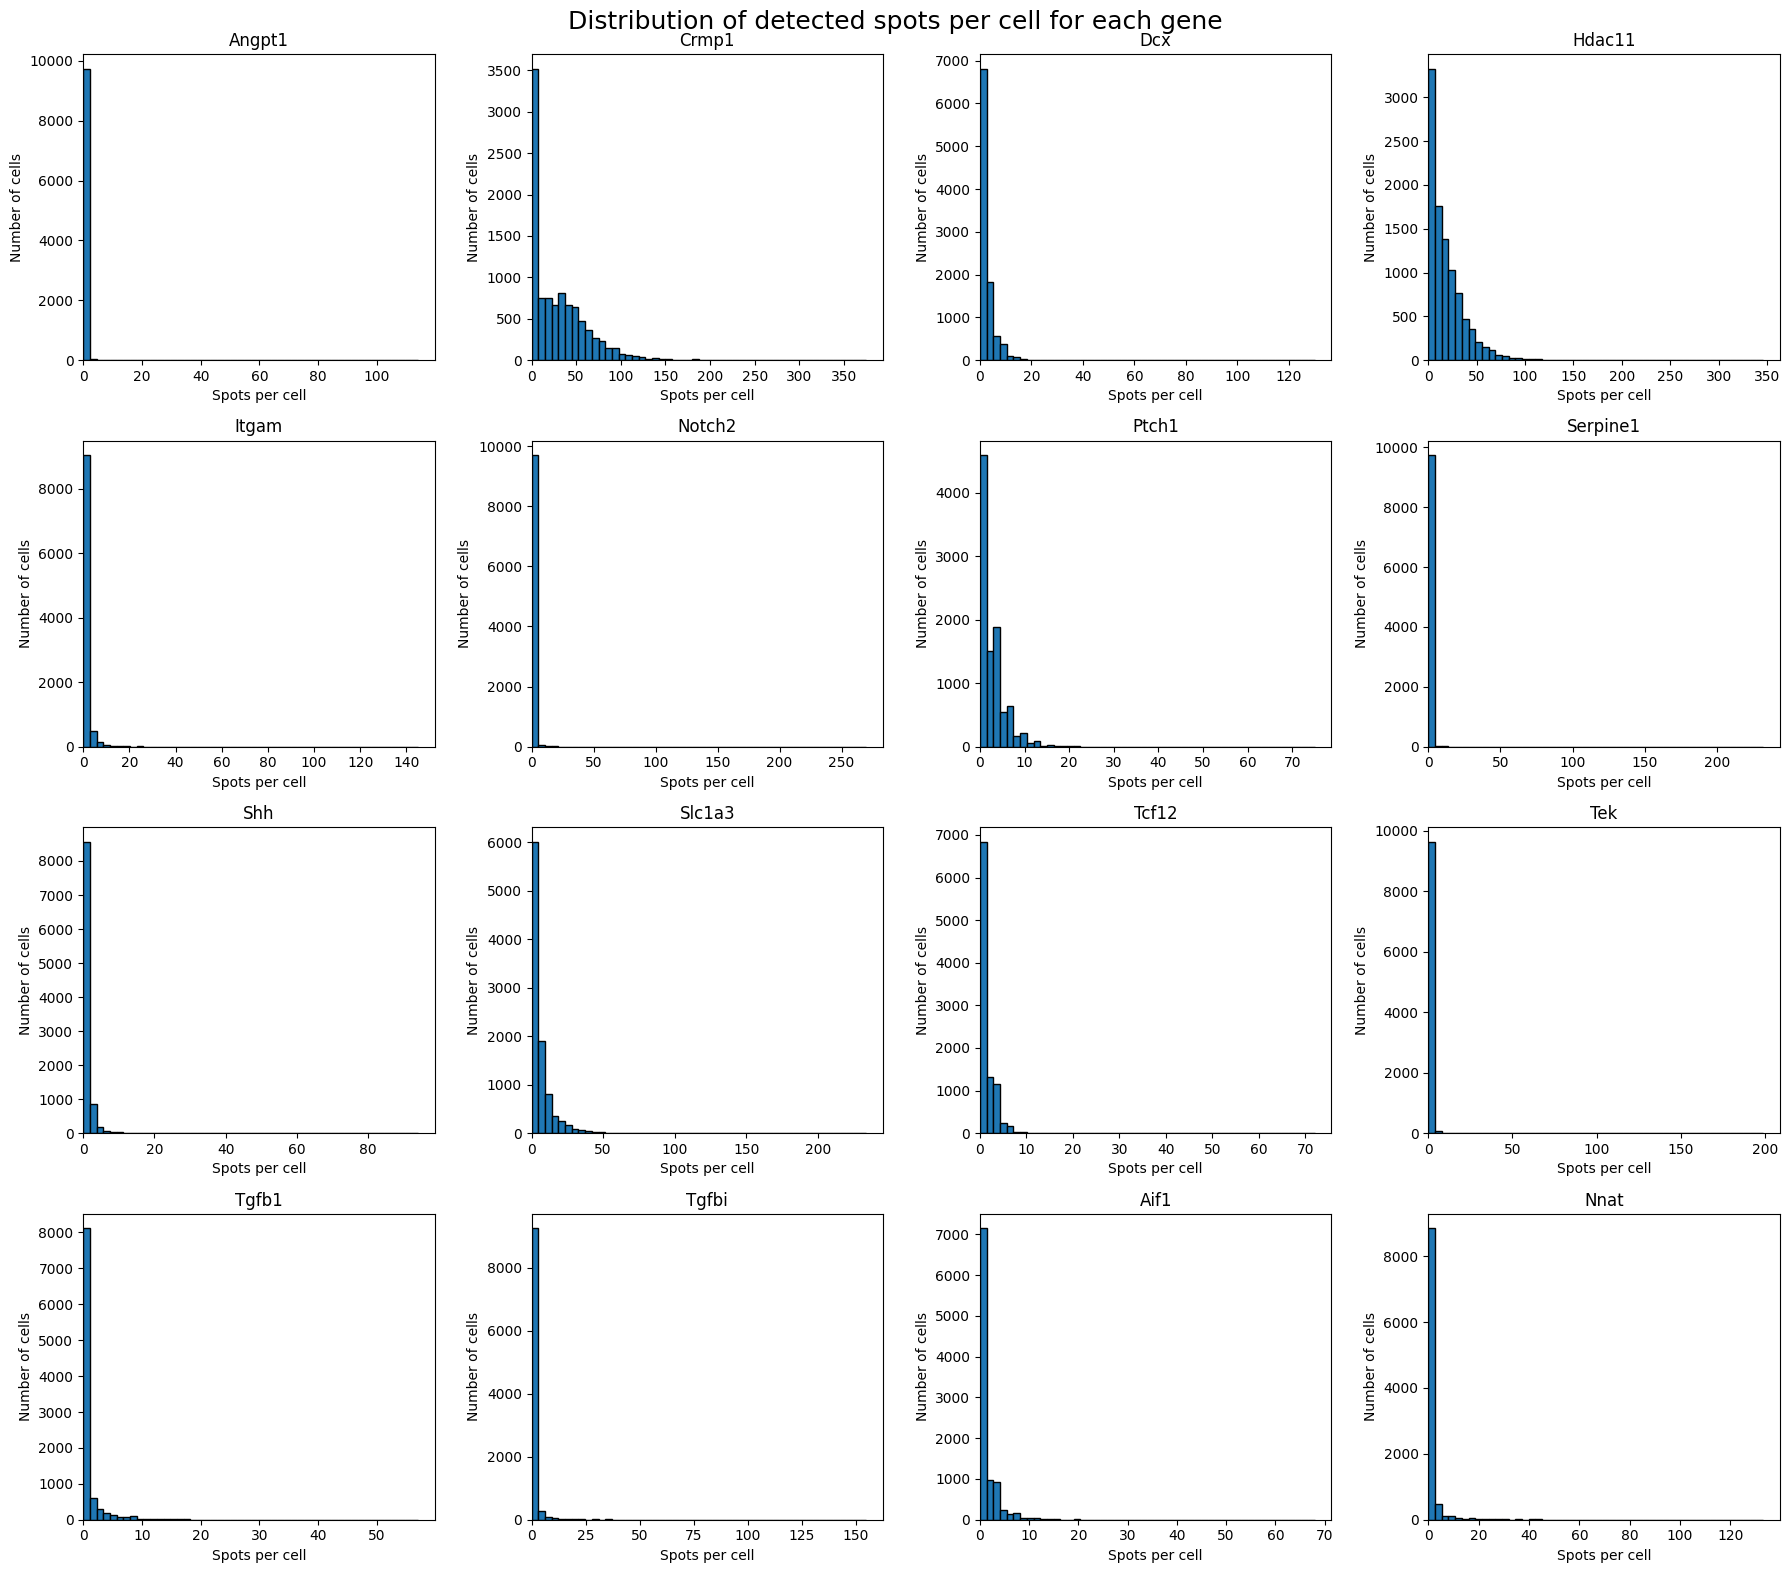

In [20]:
# Histogram of spots per cell for each gene

# Include all segmented cells, including cells with zero spots
gene_counts = (
    cell_bit_counts
    .set_index("cell_id")[gene_names]
    .reindex(cell_ids, fill_value=0)
)

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.ravel()

for ax, gene in zip(axes, gene_names):
    values = gene_counts[gene]

    ax.hist(
        values,
        bins=50,
        edgecolor="black",
    )

    ax.set_title(gene)
    ax.set_xlabel("Spots per cell")
    ax.set_ylabel("Number of cells")
    ax.set_xlim(left=0)

fig.suptitle(
    "Distribution of detected spots per cell for each gene",
    fontsize=18,
)

plt.tight_layout()

output_plot = results_dir / "histograms_spots_per_cell_all_genes.png"
plt.savefig(output_plot, dpi=300, bbox_inches="tight")

plt.show()

In [8]:
def plot_spots_per_cell_histogram(all_spots, cell_label, bit):
    """Plot the distribution of detected spots per segmented cell for one bit."""

    bit_spots = all_spots[all_spots["bit"] == bit]
    print(bit_spots)

    # Convert spot coordinates to integer pixel indices
    y = bit_spots["y"].to_numpy(dtype=int)
    x = bit_spots["x"].to_numpy(dtype=int)

    # Keep only spots inside the image
    valid = (
        (y >= 0) & (y < cell_label.shape[0]) &
        (x >= 0) & (x < cell_label.shape[1])
    )

    spot_cell_ids = cell_label[y[valid], x[valid]]
    spot_cell_ids = spot_cell_ids[spot_cell_ids > 0]

    # Include cells with zero detected spots
    n_cells = int(cell_label.max())
    spots_per_cell = np.bincount(
        spot_cell_ids.astype(int),
        minlength=n_cells + 1
    )[1:]

    max_count = max(int(spots_per_cell.max()), 1)

    plt.figure(figsize=(8, 5))
    plt.hist(
        spots_per_cell,
        bins=np.arange(-0.5, max_count + 1.5, 1),
        edgecolor="black"
    )
    plt.xlabel("Number of spots per cell")
    plt.ylabel("Number of cells")
    plt.title(f"Distribution of spots per cell — bit {bit}")
    plt.xticks(range(max_count + 1))
    plt.tight_layout()

Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
Empty DataFrame
Columns: [spot_id, y, x, bit, cell_id]
Index: []
       spot_id      y    

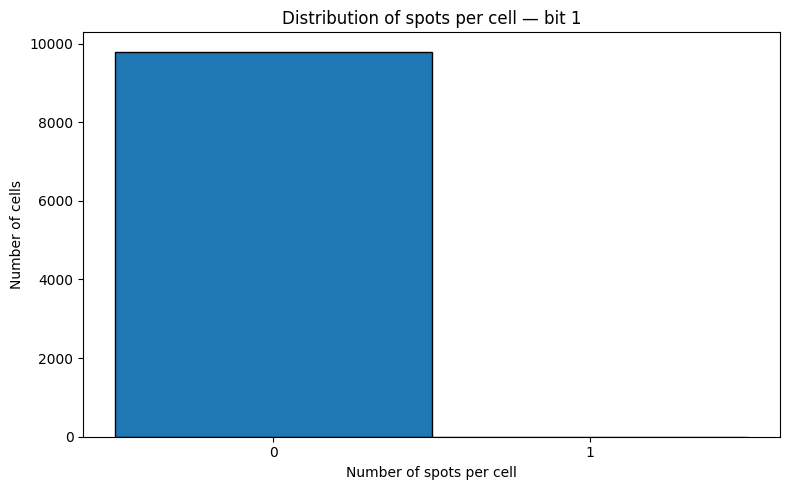

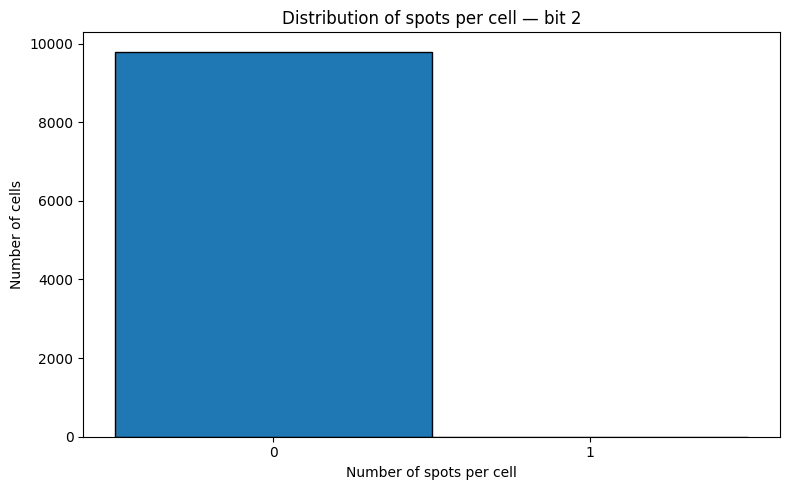

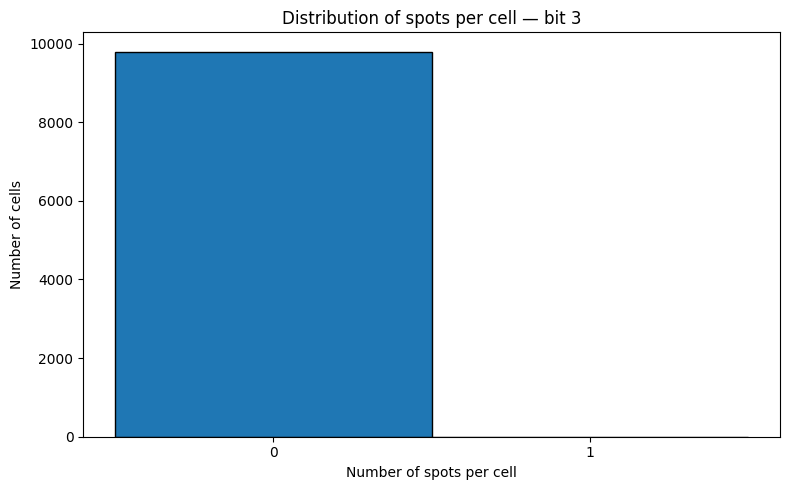

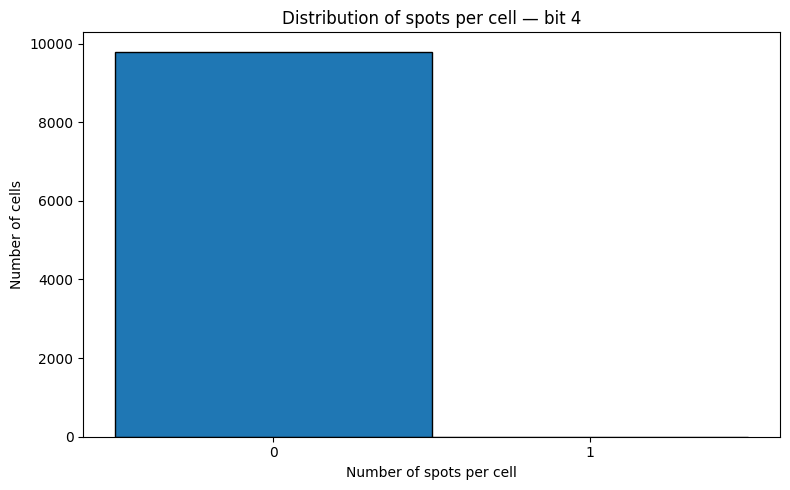

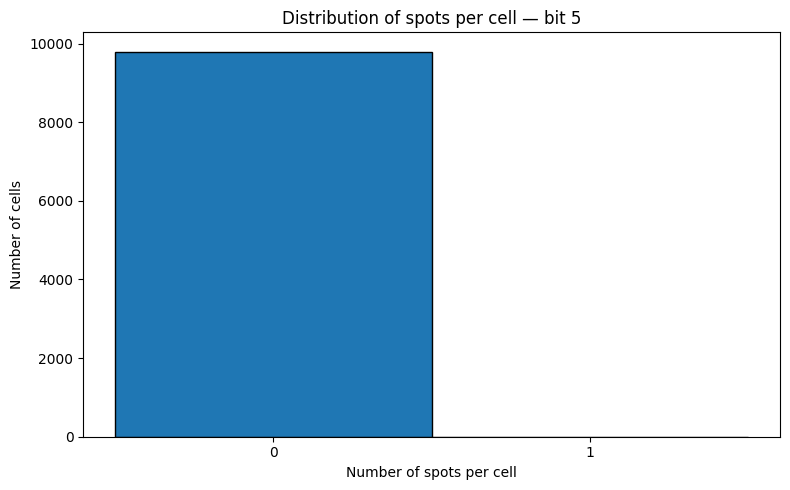

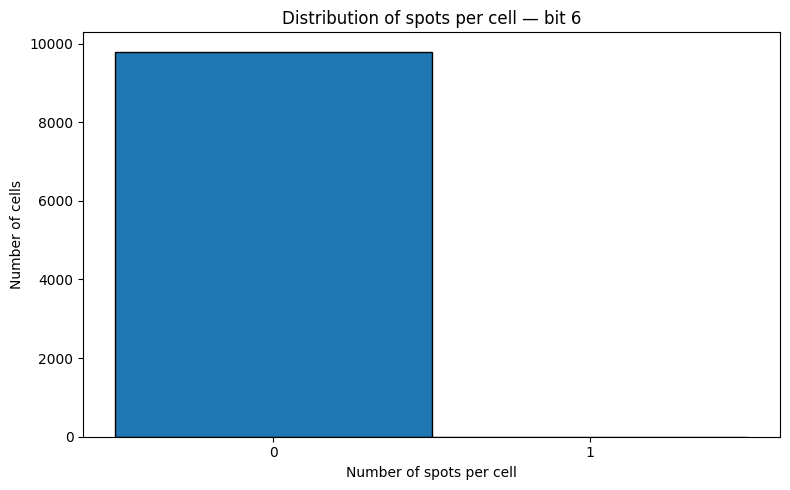

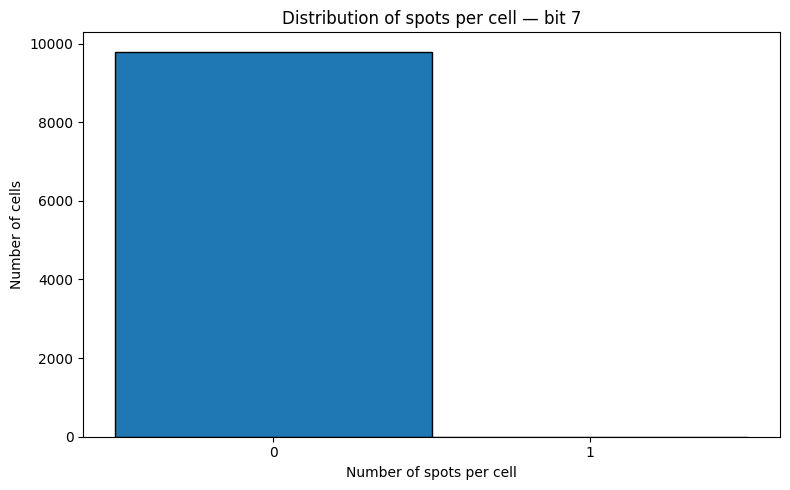

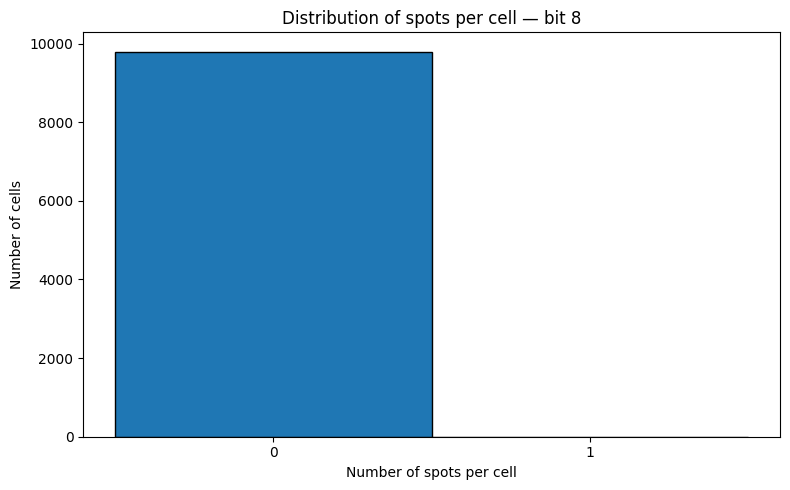

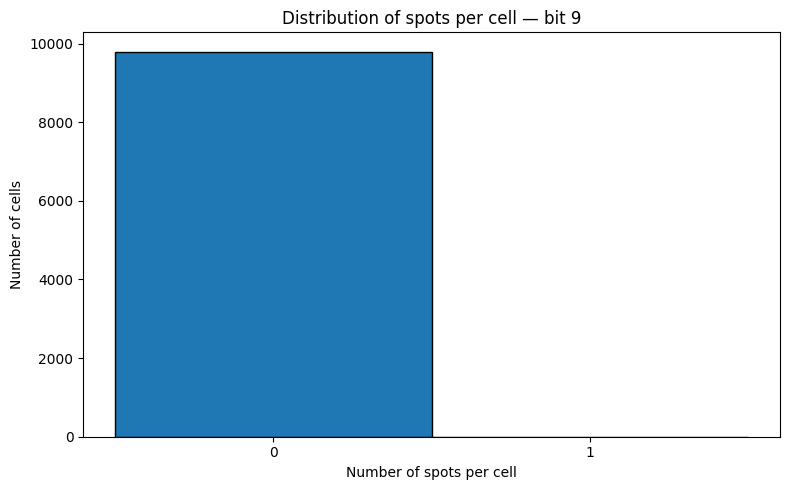

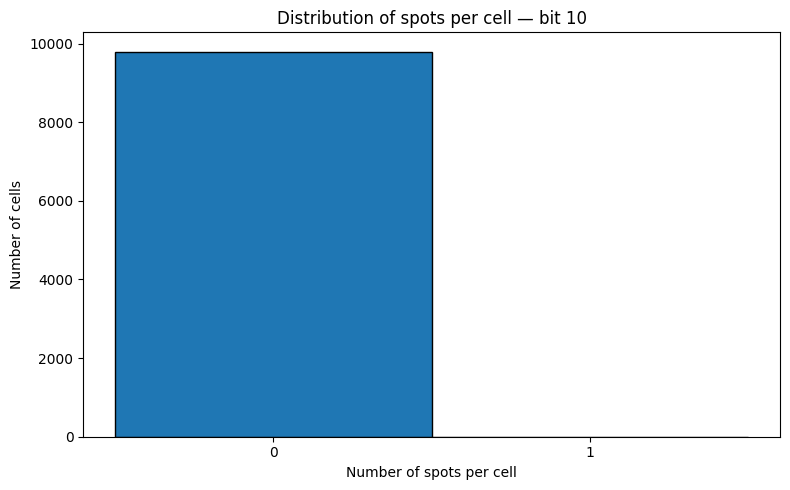

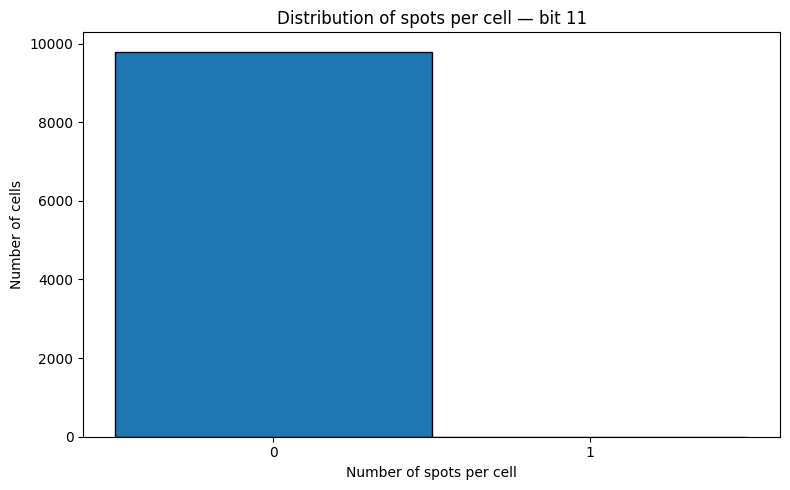

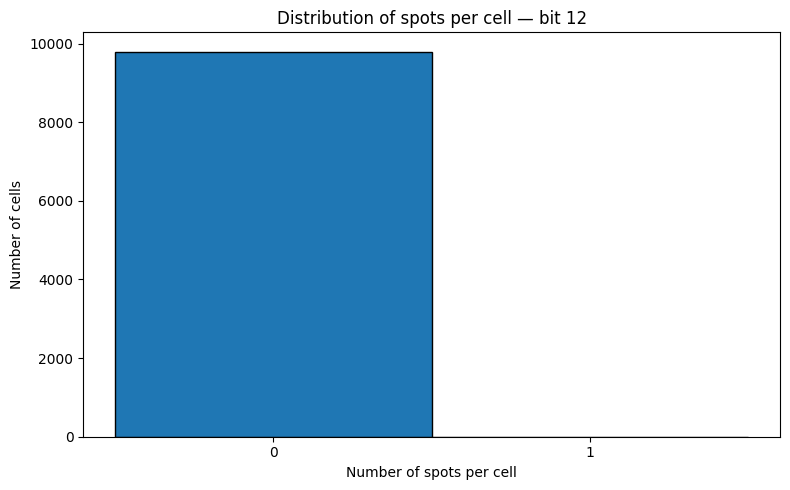

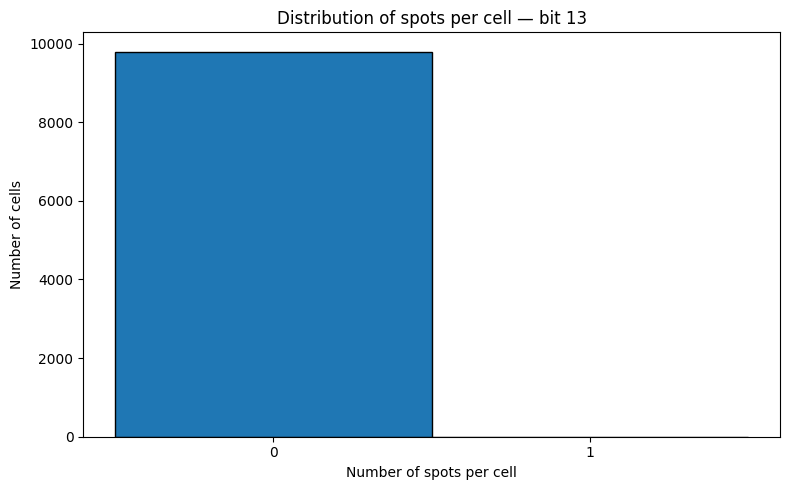

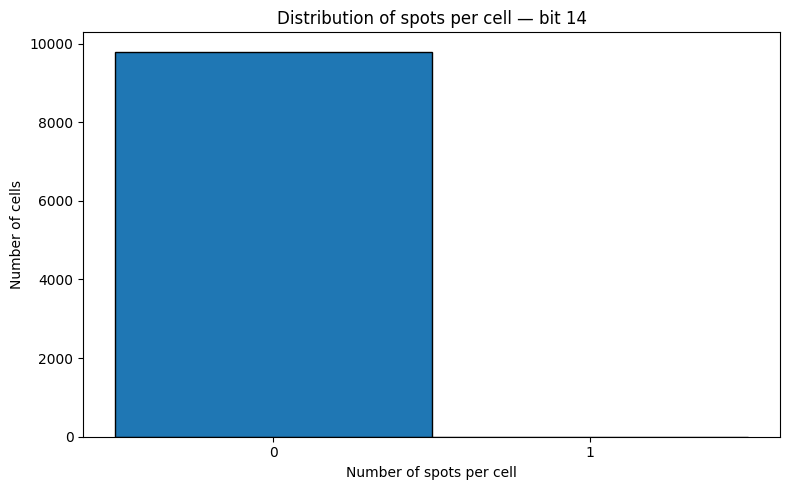

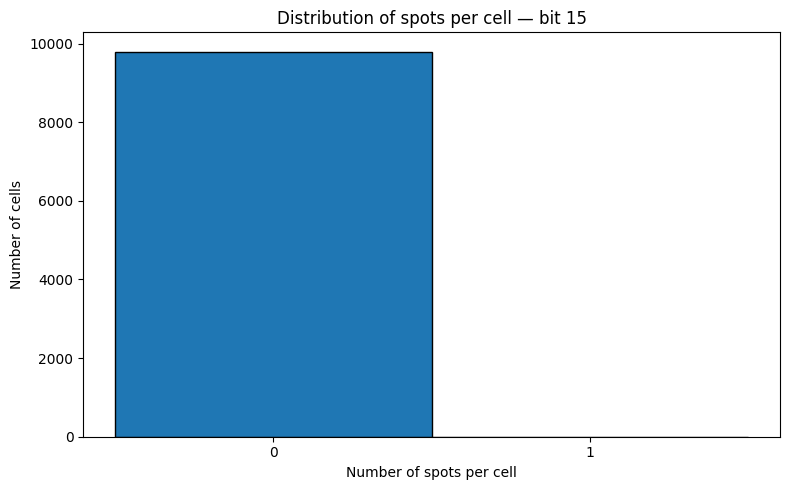

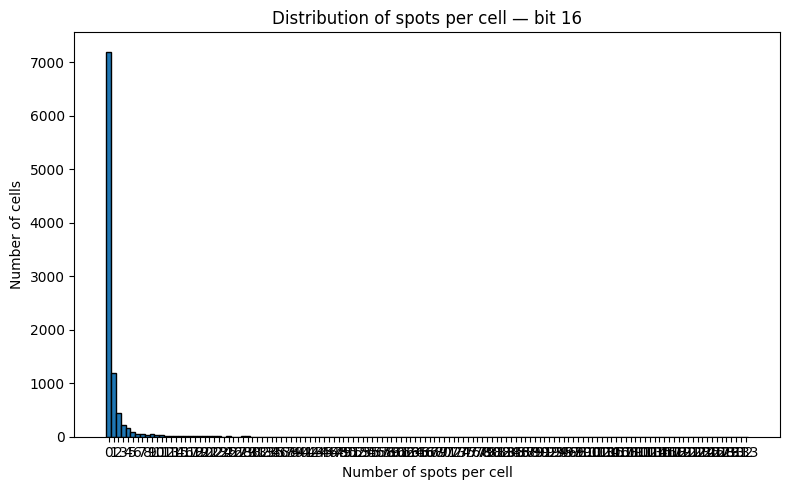

In [9]:
# Generate and display one histogram per bit
for bit in sorted(all_spots["bit"].unique()):
    plot_spots_per_cell_histogram(spots, cell_label, bit)
    # plt.show()